<a href="https://colab.research.google.com/github/devjan-07/Ai-ml-project-/blob/main/05_Custom_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/Rice_Leaf_Disease_Project"
)

RAW_DIR = PROJECT_DIR / "01_Raw_Dataset"
NOTEBOOK_DIR = PROJECT_DIR / "02_Notebooks"
RESULTS_DIR = PROJECT_DIR / "03_Results"
REPORT_DIR = PROJECT_DIR / "04_Report"

print("Project folder:", PROJECT_DIR)
print("Raw dataset folder:", RAW_DIR)
print("Notebook folder:", NOTEBOOK_DIR)
print("Results folder:", RESULTS_DIR)
print("Report folder:", REPORT_DIR)

Project folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project
Raw dataset folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/01_Raw_Dataset
Notebook folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/02_Notebooks
Results folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/03_Results
Report folder: /content/drive/MyDrive/Rice_Leaf_Disease_Project/04_Report


In [6]:
DATASET_ZIP = RAW_DIR / "rice leaf diseases dataset.zip"

print("Dataset exists:", DATASET_ZIP.exists())
print("Dataset path:", DATASET_ZIP)

Dataset exists: True
Dataset path: /content/drive/MyDrive/Rice_Leaf_Disease_Project/01_Raw_Dataset/rice leaf diseases dataset.zip


In [7]:
import zipfile

with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    files = zip_ref.namelist()

print("Total files/folders inside ZIP:", len(files))

print("\nFirst 30 entries:")
for item in files[:30]:
    print(item)

Total files/folders inside ZIP: 5932

First 30 entries:
Bacterialblight/BACTERAILBLIGHT3_001.jpg
Bacterialblight/BACTERAILBLIGHT3_002.jpg
Bacterialblight/BACTERAILBLIGHT3_003.jpg
Bacterialblight/BACTERAILBLIGHT3_004.jpg
Bacterialblight/BACTERAILBLIGHT3_005.jpg
Bacterialblight/BACTERAILBLIGHT3_006.jpg
Bacterialblight/BACTERAILBLIGHT3_007.jpg
Bacterialblight/BACTERAILBLIGHT3_008.jpg
Bacterialblight/BACTERAILBLIGHT3_009.jpg
Bacterialblight/BACTERAILBLIGHT3_010.jpg
Bacterialblight/BACTERAILBLIGHT3_011.jpg
Bacterialblight/BACTERAILBLIGHT3_012.jpg
Bacterialblight/BACTERAILBLIGHT3_013.jpg
Bacterialblight/BACTERAILBLIGHT3_014.jpg
Bacterialblight/BACTERAILBLIGHT3_015.jpg
Bacterialblight/BACTERAILBLIGHT3_016.jpg
Bacterialblight/BACTERAILBLIGHT3_017.jpg
Bacterialblight/BACTERAILBLIGHT3_018.jpg
Bacterialblight/BACTERAILBLIGHT3_019.jpg
Bacterialblight/BACTERAILBLIGHT3_020.jpg
Bacterialblight/BACTERAILBLIGHT3_021.jpg
Bacterialblight/BACTERAILBLIGHT3_022.jpg
Bacterialblight/BACTERAILBLIGHT3_023.jpg
B

In [8]:
import shutil
from pathlib import Path

EXTRACT_DIR = Path("/content/rice_leaf_dataset")

# Remove an old extraction if it exists
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

# Extract the original ZIP
with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:")
print(EXTRACT_DIR)

Dataset extracted to:
/content/rice_leaf_dataset


In [9]:
print("Top-level folders:")

for item in sorted(EXTRACT_DIR.iterdir()):
    if item.is_dir():
        print("📁", item.name)

Top-level folders:
📁 Bacterialblight
📁 Blast
📁 Brownspot
📁 Tungro


In [10]:
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

In [11]:
# Find all image files in the four disease folders
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_records = []

for class_dir in sorted(EXTRACT_DIR.iterdir()):
    if not class_dir.is_dir():
        continue

    class_name = class_dir.name

    for image_path in class_dir.rglob("*"):
        if image_path.is_file() and image_path.suffix.lower() in image_extensions:
            image_records.append({
                "image_path": str(image_path),
                "class_name": class_name
            })

dataset_df = pd.DataFrame(image_records)

print("Total image files:", len(dataset_df))
print("\nClass distribution:")
print(dataset_df["class_name"].value_counts())

Total image files: 5932

Class distribution:
class_name
Brownspot          1600
Bacterialblight    1584
Blast              1440
Tungro             1308
Name: count, dtype: int64


In [12]:
class_counts = (
    dataset_df["class_name"]
    .value_counts()
    .sort_index()
)

print(class_counts)

class_name
Bacterialblight    1584
Blast              1440
Brownspot          1600
Tungro             1308
Name: count, dtype: int64


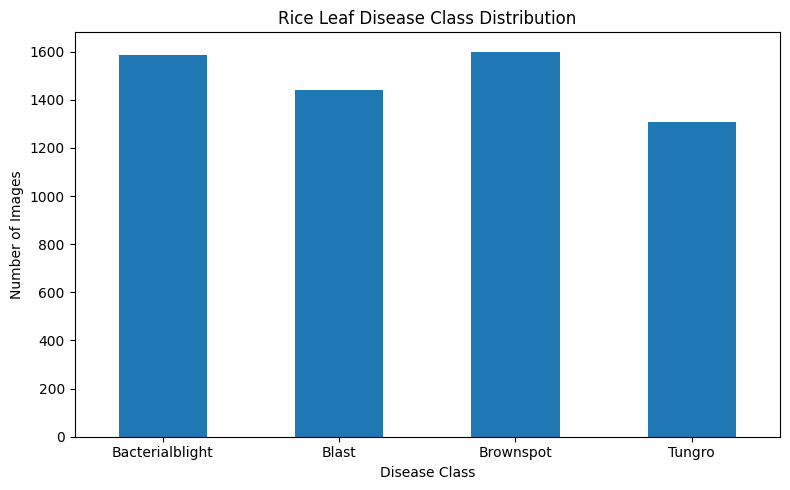

In [13]:
plt.figure(figsize=(8, 5))

class_counts.plot(kind="bar")

plt.title("Rice Leaf Disease Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
dimension_records = []
corrupt_images = []

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        with Image.open(image_path) as img:
            dimension_records.append({
                "image_path": image_path,
                "class_name": row["class_name"],
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })

    except (UnidentifiedImageError, OSError):
        corrupt_images.append(image_path)

image_info_df = pd.DataFrame(dimension_records)

print("Readable images:", len(image_info_df))
print("Corrupt/unreadable images:", len(corrupt_images))

print("\nImage modes:")
print(image_info_df["mode"].value_counts())

print("\nMost common image dimensions:")
print(
    image_info_df[["width", "height"]]
    .value_counts()
    .head(15)
)

Readable images: 5932
Corrupt/unreadable images: 0

Image modes:
mode
RGB     5776
RGBA     156
Name: count, dtype: int64

Most common image dimensions:
width  height
300    300       4624
295    221         12
499    332         12
221    295         12
521    348         11
288    216         11
381    571         10
284    426         10
331    497         10
222    296          9
359    538          9
216    288          9
538    359          9
217    289          9
219    292          9
Name: count, dtype: int64


In [15]:
AUDIT_DIR = RESULTS_DIR / "dataset_audit"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

dataset_df.to_csv(
    AUDIT_DIR / "dataset_file_list.csv",
    index=False
)

image_info_df.to_csv(
    AUDIT_DIR / "image_metadata.csv",
    index=False
)

print("Audit files saved to:")
print(AUDIT_DIR)

Audit files saved to:
/content/drive/MyDrive/Rice_Leaf_Disease_Project/03_Results/dataset_audit


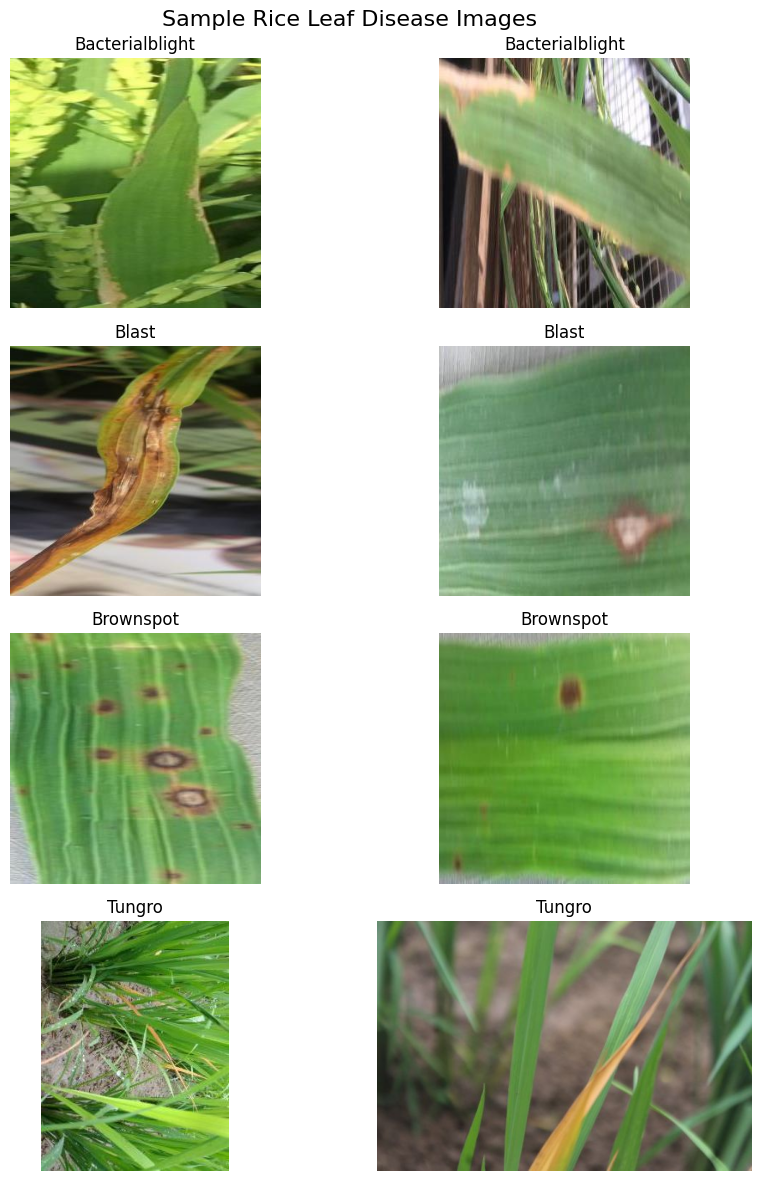

In [16]:
classes = sorted(dataset_df["class_name"].unique())

fig, axes = plt.subplots(
    len(classes),
    2,
    figsize=(10, 12)
)

for row_idx, class_name in enumerate(classes):

    class_images = dataset_df[
        dataset_df["class_name"] == class_name
    ].sample(
        n=2,
        random_state=42
    )

    for col_idx, (_, record) in enumerate(class_images.iterrows()):

        image = Image.open(
            record["image_path"]
        ).convert("RGB")

        axes[row_idx, col_idx].imshow(image)
        axes[row_idx, col_idx].set_title(
            class_name
        )
        axes[row_idx, col_idx].axis("off")

plt.suptitle(
    "Sample Rice Leaf Disease Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [17]:
import hashlib
from collections import defaultdict


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """
    Calculate the SHA-256 hash of a file.

    SHA-256 allows us to identify files that are
    exactly identical at the binary level.
    """
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while True:
            data = file.read(chunk_size)

            if not data:
                break

            sha256.update(data)

    return sha256.hexdigest()


# Dictionary:
# hash -> list of image records having that hash
hash_to_images = defaultdict(list)

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        file_hash = calculate_sha256(image_path)

        hash_to_images[file_hash].append({
            "image_path": image_path,
            "class_name": row["class_name"]
        })

    except OSError as error:
        print(f"Could not read: {image_path}")
        print(f"Reason: {error}")


# Keep only hashes that occur more than once.
duplicate_groups = {
    file_hash: records
    for file_hash, records in hash_to_images.items()
    if len(records) > 1
}

print("Total unique file hashes:", len(hash_to_images))
print("Exact duplicate groups:", len(duplicate_groups))
print(
    "Images involved in exact duplicates:",
    sum(len(records) for records in duplicate_groups.values())
)

Total unique file hashes: 4794
Exact duplicate groups: 1096
Images involved in exact duplicates: 2234


In [18]:
for group_number, (file_hash, records) in enumerate(
    duplicate_groups.items(),
    start=1
):
    print(f"\nDuplicate Group {group_number}")
    print(f"Hash: {file_hash}")

    for record in records:
        print(
            f"  {record['class_name']}: "
            f"{record['image_path']}"
        )


Duplicate Group 1
Hash: 27ec70abd8e1fe096f16e17eb98896196bc14e97c2c5205794160ec964b083ec
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT1_127.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT1_163.jpg

Duplicate Group 2
Hash: 901ff5becc8b5b33b7c6abe75ad88deec69ffecb60b72849841f2fa1b371ab12
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_170.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_186.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_182.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_180.jpg
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERAILBLIGHT5_184.jpg

Duplicate Group 3
Hash: 6881ec362e5579b81dddca397415c95cc8f98615602b0a20c7f0a2fbbfafe1b8
  Bacterialblight: /content/rice_leaf_dataset/Bacterialblight/BACTERIALBLIGHT2_256.jpg
  Bacterialblight: /content/rice_l

In [19]:
cross_class_duplicate_groups = {}

for file_hash, records in duplicate_groups.items():

    classes = {
        record["class_name"]
        for record in records
    }

    if len(classes) > 1:
        cross_class_duplicate_groups[file_hash] = records


print(
    "Exact duplicate groups appearing across "
    "multiple classes:",
    len(cross_class_duplicate_groups)
)

Exact duplicate groups appearing across multiple classes: 0


In [20]:
# Create a mapping from image path to its SHA-256 hash.
image_hash_records = []

for _, row in dataset_df.iterrows():
    image_path = row["image_path"]

    try:
        file_hash = calculate_sha256(image_path)

        image_hash_records.append({
            "image_path": image_path,
            "class_name": row["class_name"],
            "file_hash": file_hash
        })

    except OSError as error:
        print(f"Could not read: {image_path}")
        print(f"Reason: {error}")


# Create a dataframe containing hash information.
hashed_df = pd.DataFrame(image_hash_records)

print("Total images before deduplication:", len(hashed_df))
print("Unique images after deduplication:",
      hashed_df["file_hash"].nunique())

Total images before deduplication: 5932
Unique images after deduplication: 4794


In [21]:
# Keep the first occurrence of each exact duplicate group.
deduplicated_df = hashed_df.drop_duplicates(
    subset="file_hash",
    keep="first"
).reset_index(drop=True)


print("Images before deduplication:", len(hashed_df))
print("Images after deduplication:", len(deduplicated_df))
print(
    "Images removed:",
    len(hashed_df) - len(deduplicated_df)
)

Images before deduplication: 5932
Images after deduplication: 4794
Images removed: 1138


In [22]:
deduplicated_class_counts = (
    deduplicated_df["class_name"]
    .value_counts()
    .sort_index()
)

print("Class distribution after deduplication:")
print(deduplicated_class_counts)

Class distribution after deduplication:
class_name
Bacterialblight    1326
Blast               960
Brownspot          1200
Tungro             1308
Name: count, dtype: int64


In [23]:
deduplicated_class_percentages = (
    deduplicated_df["class_name"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print("\nClass percentages after deduplication:")
print(deduplicated_class_percentages.round(2))


Class percentages after deduplication:
class_name
Bacterialblight    27.66
Blast              20.03
Brownspot          25.03
Tungro             27.28
Name: proportion, dtype: float64


In [24]:
duplicate_group_sizes = (
    hashed_df.groupby("file_hash")
    .size()
)

print("Duplicate group size distribution:")
print(
    duplicate_group_sizes[
        duplicate_group_sizes > 1
    ].value_counts().sort_index()
)

Duplicate group size distribution:
2    1078
3       6
5      12
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# Step 1: Create the training and temporary datasets
# ---------------------------------------------------------

train_df, temp_df = train_test_split(
    deduplicated_df,
    test_size=0.30,
    stratify=deduplicated_df["class_name"],
    random_state=42
)

# ---------------------------------------------------------
# Step 2: Split the temporary dataset equally
# into validation and testing datasets
# ---------------------------------------------------------

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class_name"],
    random_state=42
)

# Reset dataframe indexes
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ---------------------------------------------------------
# Display dataset sizes
# ---------------------------------------------------------

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Total images:", len(train_df) + len(val_df) + len(test_df))

Training images: 3355
Validation images: 719
Testing images: 720
Total images: 4794


In [26]:
def show_class_distribution(dataframe, dataset_name):
    """Display class counts and percentages for a dataset split."""

    counts = dataframe["class_name"].value_counts().sort_index()

    percentages = (
        dataframe["class_name"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    distribution = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    print(f"\n{dataset_name}")
    print("-" * len(dataset_name))
    print(distribution)


show_class_distribution(train_df, "Training Set")
show_class_distribution(val_df, "Validation Set")
show_class_distribution(test_df, "Test Set")


Training Set
------------
                 Count  Percentage
class_name                        
Bacterialblight    928       27.66
Blast              672       20.03
Brownspot          840       25.04
Tungro             915       27.27

Validation Set
--------------
                 Count  Percentage
class_name                        
Bacterialblight    199       27.68
Blast              144       20.03
Brownspot          180       25.03
Tungro             196       27.26

Test Set
--------
                 Count  Percentage
class_name                        
Bacterialblight    199       27.64
Blast              144       20.00
Brownspot          180       25.00
Tungro             197       27.36


In [27]:
train_paths = set(train_df["image_path"])
val_paths = set(val_df["image_path"])
test_paths = set(test_df["image_path"])

print("Train-Val overlap:", len(train_paths & val_paths))
print("Train-Test overlap:", len(train_paths & test_paths))
print("Val-Test overlap:", len(val_paths & test_paths))

Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [28]:
from pathlib import Path

import cv2
import pandas as pd


def inspect_image(image_path):
    """
    Inspect an image and return its basic properties.

    Returns:
        dict: Image properties or an error message.
    """
    try:
        image = cv2.imread(str(image_path), cv2.IMREAD_UNCHANGED)

        if image is None:
            return {
                "valid": False,
                "width": None,
                "height": None,
                "channels": None,
                "aspect_ratio": None,
                "format": Path(image_path).suffix.lower(),
                "error": "Could not decode image"
            }

        height, width = image.shape[:2]

        if len(image.shape) == 2:
            channels = 1
        else:
            channels = image.shape[2]

        aspect_ratio = width / height

        return {
            "valid": True,
            "width": width,
            "height": height,
            "channels": channels,
            "aspect_ratio": aspect_ratio,
            "format": Path(image_path).suffix.lower(),
            "error": None
        }

    except Exception as error:
        return {
            "valid": False,
            "width": None,
            "height": None,
            "channels": None,
            "aspect_ratio": None,
            "format": Path(image_path).suffix.lower(),
            "error": str(error)
        }


inspection_results = []

for image_path in deduplicated_df["image_path"]:

    result = inspect_image(image_path)
    result["image_path"] = image_path

    inspection_results.append(result)


image_audit_df = pd.DataFrame(inspection_results)

print("Image audit completed.")
print("Total images inspected:", len(image_audit_df))

Image audit completed.
Total images inspected: 4794


In [29]:
valid_count = image_audit_df["valid"].sum()
invalid_count = (~image_audit_df["valid"]).sum()

print("Valid images:", valid_count)
print("Invalid/corrupted images:", invalid_count)

Valid images: 4794
Invalid/corrupted images: 0


In [30]:
print("\nWidth statistics:")
print(image_audit_df["width"].describe())

print("\nHeight statistics:")
print(image_audit_df["height"].describe())


Width statistics:
count    4794.000000
mean      315.150188
std        59.051438
min       209.000000
25%       300.000000
50%       300.000000
75%       300.000000
max       603.000000
Name: width, dtype: float64

Height statistics:
count    4794.000000
mean      315.100542
std        59.083475
min       209.000000
25%       300.000000
50%       300.000000
75%       300.000000
max       603.000000
Name: height, dtype: float64


In [31]:
dimension_counts = (
    image_audit_df[
        image_audit_df["valid"]
    ]
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
)

print("\nMost common image dimensions:")
print(dimension_counts.head(20))


Most common image dimensions:
width  height
300    300       3486
295    221         12
499    332         12
221    295         12
521    348         11
288    216         11
381    571         10
284    426         10
331    497         10
222    296          9
359    538          9
216    288          9
538    359          9
217    289          9
219    292          9
497    331          9
493    329          9
571    381          9
426    284          9
537    358          8
dtype: int64


In [32]:
print("\nAspect ratio statistics:")
print(
    image_audit_df["aspect_ratio"].describe()
)


Aspect ratio statistics:
count    4794.000000
mean        1.019230
std         0.201614
min         0.663657
25%         1.000000
50%         1.000000
75%         1.000000
max         1.506803
Name: aspect_ratio, dtype: float64


In [33]:
print("\nImages with unusual aspect ratios:")

unusual_aspect_ratios = image_audit_df[
    (image_audit_df["aspect_ratio"] < 0.75) |
    (image_audit_df["aspect_ratio"] > 1.33)
]

print(
    "Number of unusual aspect-ratio images:",
    len(unusual_aspect_ratios)
)


Images with unusual aspect ratios:
Number of unusual aspect-ratio images: 1153


In [34]:
print("\nChannel distribution:")
print(
    image_audit_df["channels"]
    .value_counts()
    .sort_index()
)


Channel distribution:
channels
3    4650
4     144
Name: count, dtype: int64


In [35]:
print("\nImage format distribution:")
print(
    image_audit_df["format"]
    .value_counts()
)


Image format distribution:
format
.jpg    4794
Name: count, dtype: int64


In [36]:
import numpy as np
import tensorflow as tf


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------

IMAGE_SIZE = 224
BATCH_SIZE = 32
RANDOM_SEED = 42

CLASS_NAMES = [
    "Bacterialblight",
    "Blast",
    "Brownspot",
    "Tungro"
]

CLASS_TO_INDEX = {
    class_name: index
    for index, class_name in enumerate(CLASS_NAMES)
}

NUM_CLASSES = len(CLASS_NAMES)

print("Class mapping:")
for class_name, index in CLASS_TO_INDEX.items():
    print(f"{class_name}: {index}")

print("Number of classes:", NUM_CLASSES)

Class mapping:
Bacterialblight: 0
Blast: 1
Brownspot: 2
Tungro: 3
Number of classes: 4


In [37]:
def create_file_dataset(dataframe):
    """
    Create a TensorFlow dataset containing image paths
    and integer class labels.
    """

    image_paths = dataframe["image_path"].astype(str).values

    labels = dataframe["class_name"].map(
        CLASS_TO_INDEX
    ).values.astype(np.int32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    return dataset


train_raw_ds = create_file_dataset(train_df)
val_raw_ds = create_file_dataset(val_df)
test_raw_ds = create_file_dataset(test_df)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 3355
Validation samples: 719
Testing samples: 720


In [38]:
def load_image(image_path, label):
    """
    Load an image from disk and convert it to RGB.

    Returns:
        image: Tensor with shape (height, width, 3)
        label: Integer class label
    """

    image = tf.io.read_file(image_path)

    image = tf.io.decode_jpeg(
        image,
        channels=3
    )

    image = tf.cast(image, tf.float32)

    return image, label

In [39]:
def resize_image(image, label):
    """
    Resize an image directly to 224 x 224 pixels.
    """

    image = tf.image.resize(
        image,
        size=[224, 224],
        method="bilinear"
    )

    return image, label

In [40]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.08
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.10,
            width_factor=0.10
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="data_augmentation"
)

In [41]:
def preprocess_for_cnn(
    image_path,
    label,
    training=False
):
    """
    Load, resize, optionally augment, and normalize
    an image for the Custom CNN.
    """

    image, label = load_image(
        image_path,
        label
    )

    image, label = resize_image(
        image,
        label
    )

    image = image / 255.0

    if training:
        image = data_augmentation(
            image,
            training=True
        )

    return image, label

In [42]:
AUTOTUNE = tf.data.AUTOTUNE

train_cnn_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=True
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_cnn_ds = (
    val_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_cnn_ds = (
    test_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_cnn(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [43]:
val_images, val_labels = next(iter(val_cnn_ds))

print(val_images.shape)
print(
    tf.reduce_min(val_images).numpy(),
    tf.reduce_max(val_images).numpy()
)

(32, 224, 224, 3)
0.0 1.0


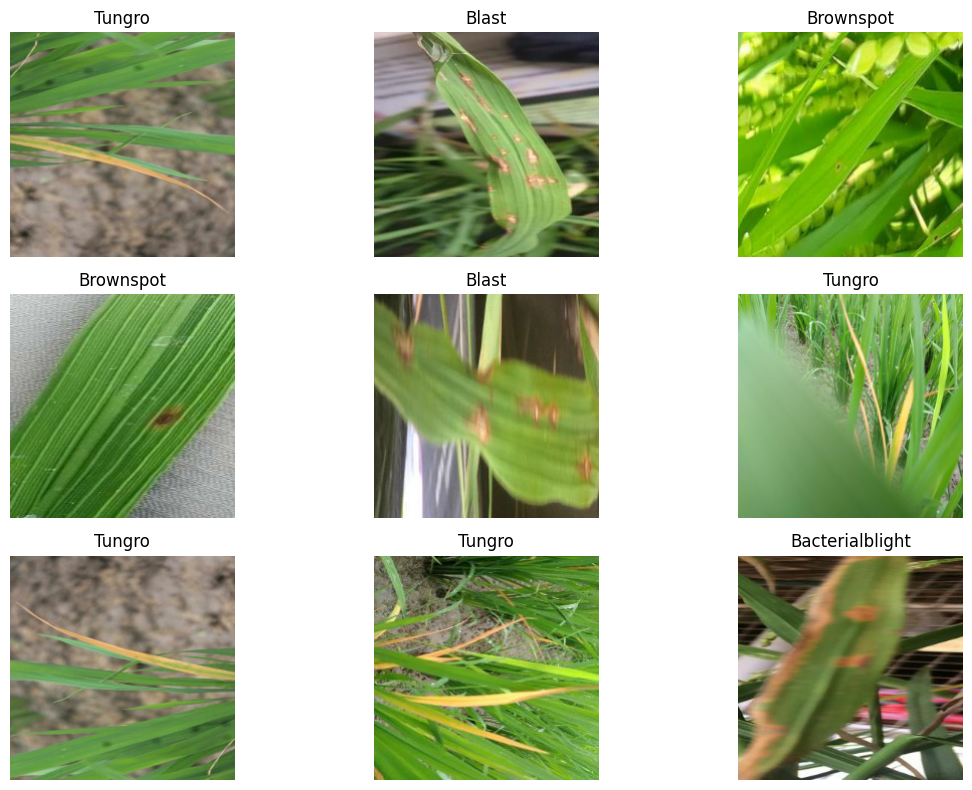

In [44]:
val_images, val_labels = next(iter(val_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(val_images[index])

    class_index = int(val_labels[index].numpy())

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [45]:
images, labels = next(iter(train_cnn_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Unique labels: [0 1 2 3]


In [46]:
images, labels = next(iter(train_cnn_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: 0.0
Maximum pixel value: 0.99997765
Unique labels: [0 1 2 3]


In [47]:
print("Batch labels:")
print(labels.numpy())

print("\nUnique labels in batch:")
print(np.unique(labels.numpy()))

Batch labels:
[1 2 2 3 3 1 2 2 3 0 0 1 1 1 1 2 2 2 1 2 3 0 1 3 2 0 2 2 2 2 2 2]

Unique labels in batch:
[0 1 2 3]


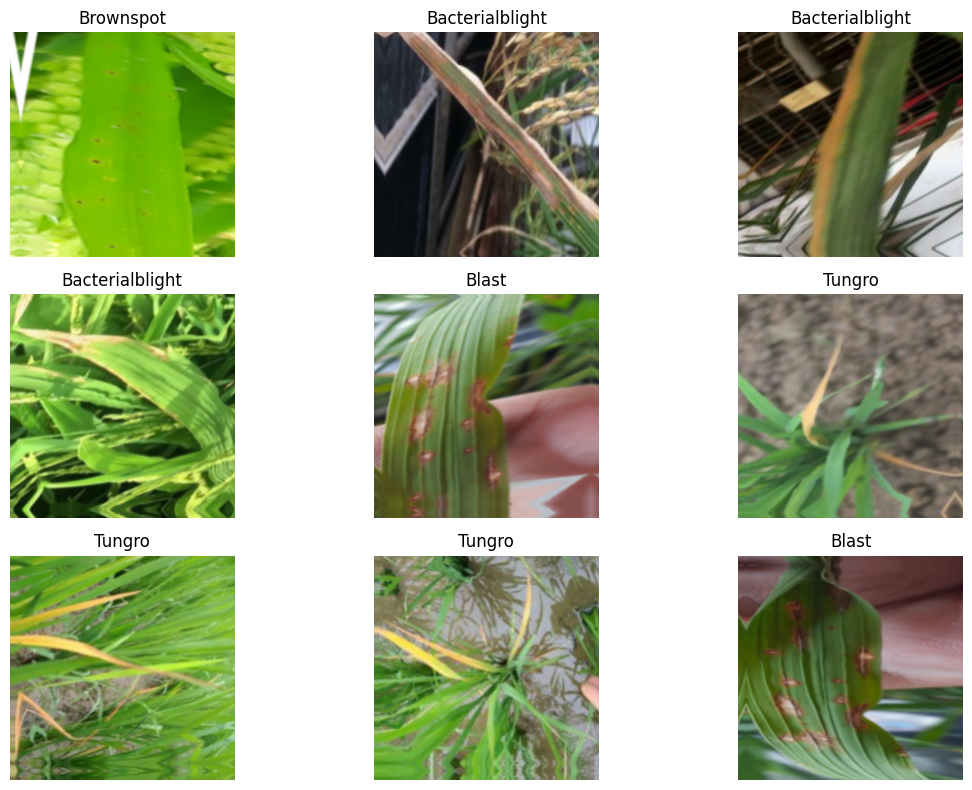

In [48]:
import matplotlib.pyplot as plt


images, labels = next(iter(train_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(images[index])

    class_index = int(
        labels[index].numpy()
    )

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

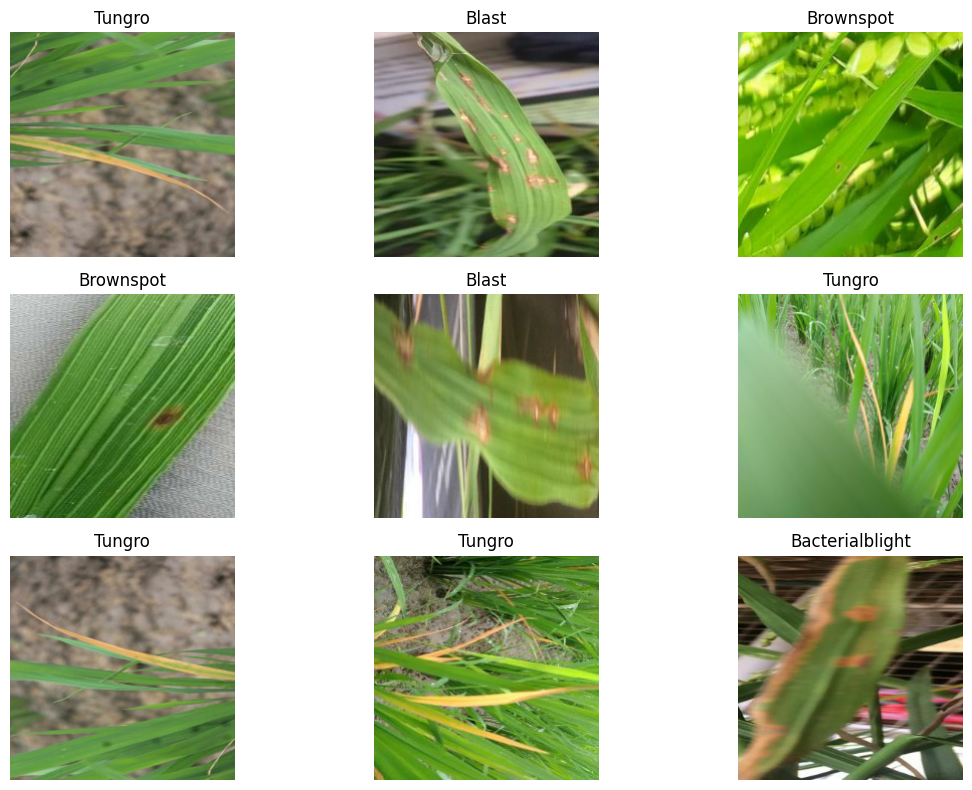

In [49]:
val_images, val_labels = next(iter(val_cnn_ds))

plt.figure(figsize=(12, 8))

for index in range(9):
    plt.subplot(3, 3, index + 1)

    plt.imshow(val_images[index])

    class_index = int(
        val_labels[index].numpy()
    )

    plt.title(CLASS_NAMES[class_index])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
from tensorflow.keras.applications.mobilenet_v2 import (
    preprocess_input
)

In [51]:
def preprocess_for_mobilenet(
    image_path,
    label,
    training=False
):
    """
    Load, resize, optionally augment, and preprocess
    an image for MobileNetV2.

    Args:
        image_path: Path to the image.
        label: Integer class label.
        training: Whether the image belongs to training data.

    Returns:
        Preprocessed image and integer label.
    """

    image, label = load_image(
        image_path,
        label
    )

    image, label = resize_image(
        image,
        label
    )

    # Apply augmentation only to training images.
    if training:
        image = data_augmentation(
            image,
            training=True
        )

    # MobileNetV2 preprocessing.
    image = preprocess_input(image)

    return image, label

In [52]:
AUTOTUNE = tf.data.AUTOTUNE


train_mobilenet_ds = (
    train_raw_ds
    .shuffle(
        buffer_size=len(train_df),
        seed=RANDOM_SEED,
        reshuffle_each_iteration=True
    )
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=True
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_mobilenet_ds = (
    val_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


test_mobilenet_ds = (
    test_raw_ds
    .map(
        lambda image_path, label:
        preprocess_for_mobilenet(
            image_path,
            label,
            training=False
        ),
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [53]:
images, labels = next(iter(train_mobilenet_ds))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Minimum pixel value:",
    tf.reduce_min(images).numpy()
)

print(
    "Maximum pixel value:",
    tf.reduce_max(images).numpy()
)

print(
    "Unique labels:",
    np.unique(labels.numpy())
)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: -1.0
Maximum pixel value: 1.0
Unique labels: [0 1 2 3]


In [54]:
val_images, val_labels = next(
    iter(val_mobilenet_ds)
)

print(
    "Validation batch shape:",
    val_images.shape
)

print(
    "Validation label shape:",
    val_labels.shape
)

print(
    "Validation unique labels:",
    np.unique(val_labels.numpy())
)

Validation batch shape: (32, 224, 224, 3)
Validation label shape: (32,)
Validation unique labels: [0 1 2 3]


In [55]:
def display_mobilenet_images(
    images,
    labels
):
    """
    Convert MobileNetV2-preprocessed images back to
    displayable RGB values and visualize them.
    """

    display_images = (
        images + 1.0
    ) * 127.5

    display_images = tf.clip_by_value(
        display_images,
        0.0,
        255.0
    )

    display_images = (
        display_images / 255.0
    )

    plt.figure(figsize=(12, 8))

    for index in range(9):
        plt.subplot(3, 3, index + 1)

        plt.imshow(
            display_images[index]
        )

        class_index = int(
            labels[index].numpy()
        )

        plt.title(
            CLASS_NAMES[class_index]
        )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

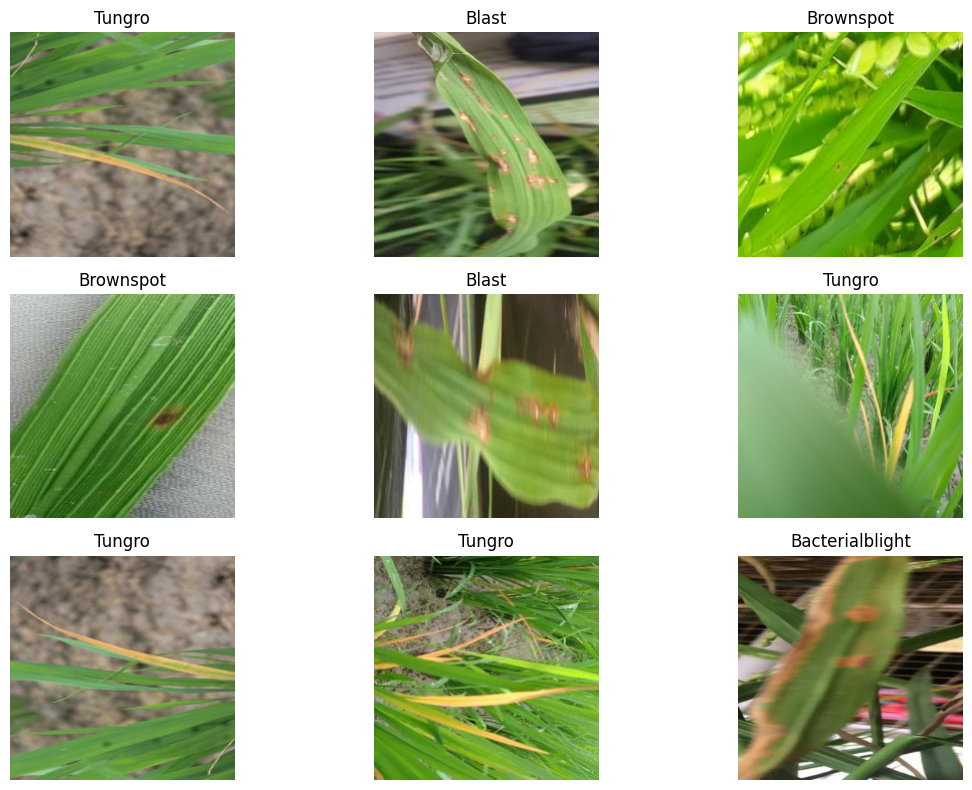

In [56]:
display_mobilenet_images(
    val_images,
    val_labels
)

In [57]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

In [58]:
def extract_color_features(image_path):
    """
    Extract statistical colour features from an image.

    Features:
        - RGB mean and standard deviation
        - HSV mean and standard deviation

    Returns:
        Dictionary containing colour features.
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # OpenCV loads images as BGR.
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Convert RGB image to HSV.
    image_hsv = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2HSV
    )

    features = {}

    # RGB statistics
    rgb_channels = ["R", "G", "B"]

    for index, channel in enumerate(rgb_channels):
        features[f"{channel}_mean"] = np.mean(
            image_rgb[:, :, index]
        )

        features[f"{channel}_std"] = np.std(
            image_rgb[:, :, index]
        )

    # HSV statistics
    hsv_channels = ["H", "S", "V"]

    for index, channel in enumerate(hsv_channels):
        features[f"{channel}_mean"] = np.mean(
            image_hsv[:, :, index]
        )

        features[f"{channel}_std"] = np.std(
            image_hsv[:, :, index]
        )

    return features

In [59]:
sample_path = train_df.iloc[0]["image_path"]

sample_color_features = extract_color_features(
    sample_path
)

print(sample_color_features)

{'R_mean': np.float64(89.43586666666667), 'R_std': np.float64(60.967701633496986), 'G_mean': np.float64(85.60853333333333), 'G_std': np.float64(56.11609729900246), 'B_mean': np.float64(74.75208888888889), 'B_std': np.float64(50.229667263623405), 'H_mean': np.float64(59.33722222222222), 'H_std': np.float64(49.729154572606326), 'S_mean': np.float64(71.41531111111111), 'S_std': np.float64(35.65228160086889), 'V_mean': np.float64(95.96912222222223), 'V_std': np.float64(60.20803777926587)}


In [60]:
from skimage.feature import graycomatrix, graycoprops


def extract_texture_features(image_path):
    """
    Extract texture features using GLCM.

    Features:
        - Contrast
        - Dissimilarity
        - Homogeneity
        - Energy
        - Correlation

    Returns:
        Dictionary containing texture features.
    """

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise ValueError(
            f"Could not read image: {image_path}"
        )

    # Reduce the number of gray levels.
    image = cv2.resize(
        image,
        (128, 128)
    )

    image = (image / 32).astype(np.uint8)

    # Create the GLCM.
    glcm = graycomatrix(
        image,
        distances=[1],
        angles=[0],
        levels=8,
        symmetric=True,
        normed=True
    )

    features = {
        "texture_contrast": graycoprops(
            glcm, "contrast"
        )[0, 0],

        "texture_dissimilarity": graycoprops(
            glcm, "dissimilarity"
        )[0, 0],

        "texture_homogeneity": graycoprops(
            glcm, "homogeneity"
        )[0, 0],

        "texture_energy": graycoprops(
            glcm, "energy"
        )[0, 0],

        "texture_correlation": graycoprops(
            glcm, "correlation"
        )[0, 0]
    }

    return features

In [61]:
sample_texture_features = extract_texture_features(
    sample_path
)

print(sample_texture_features)

{'texture_contrast': np.float64(0.6766732283464567), 'texture_dissimilarity': np.float64(0.4157234251968504), 'texture_homogeneity': np.float64(0.816455493442814), 'texture_energy': np.float64(0.3213770669162323), 'texture_correlation': np.float64(0.8896818754015047)}


In [62]:
# ============================================================
# FINAL CLASSICAL ML DATASET
# Use the deduplicated dataset established during data cleaning
# ============================================================

# Use one representative image from each exact-duplicate group
final_ml_df = deduplicated_df.copy()

# Recreate image paths and labels for Member 4 feature extraction
image_paths = final_ml_df["image_path"].tolist()
labels = final_ml_df["class_name"].tolist()

print("Images used for classical ML:", len(image_paths))
print("Number of labels:", len(labels))
print("Classes:", sorted(set(labels)))

Images used for classical ML: 4794
Number of labels: 4794
Classes: ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']


In [63]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage import img_as_ubyte

In [64]:
def texture_features(img_bgr):
    """
    Extract the four GLCM texture features used in Progress I.
    """

    gray = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2GRAY
    )

    gray = img_as_ubyte(gray)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(
        glcm,
        "contrast"
    )[0, 0]

    homogeneity = graycoprops(
        glcm,
        "homogeneity"
    )[0, 0]

    energy = graycoprops(
        glcm,
        "energy"
    )[0, 0]

    correlation = graycoprops(
        glcm,
        "correlation"
    )[0, 0]

    return (
        contrast,
        homogeneity,
        energy,
        correlation
    )

In [65]:
def get_leaf_roi_final(img_bgr):
    """
    Create the final leaf ROI used in Progress I.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_green = np.array(
        [25, 40, 40]
    )

    upper_green = np.array(
        [95, 255, 255]
    )

    green_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    kernel = np.ones(
        (7, 7),
        np.uint8
    )

    green_mask = cv2.morphologyEx(
        green_mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    num_labels, label_map, stats, _ = (
        cv2.connectedComponentsWithStats(
            green_mask,
            connectivity=8
        )
    )

    if num_labels <= 1:
        return green_mask

    largest_label = (
        1
        + np.argmax(
            stats[
                1:,
                cv2.CC_STAT_AREA
            ]
        )
    )

    leaf_roi = np.uint8(
        label_map == largest_label
    ) * 255

    leaf_roi = cv2.dilate(
        leaf_roi,
        np.ones((25, 25), np.uint8)
    )

    return leaf_roi


def lesion_count_final(
    img_bgr,
    min_area=80
):
    """
    Count disease-region contours inside
    the final leaf ROI.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    kernel = np.ones(
        (3, 3),
        np.uint8
    )

    disease_mask = cv2.morphologyEx(
        disease_mask,
        cv2.MORPH_OPEN,
        kernel
    )

    contours, _ = cv2.findContours(
        disease_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    valid_contours = [
        contour
        for contour in contours
        if cv2.contourArea(contour) >= min_area
    ]

    return len(valid_contours)


def lesion_area_ratio_final(img_bgr):
    """
    Calculate the final disease-area ratio
    used in Progress I.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_green = np.array(
        [25, 40, 40]
    )

    upper_green = np.array(
        [95, 255, 255]
    )

    green_mask = cv2.inRange(
        hsv,
        lower_green,
        upper_green
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    green_mask = cv2.bitwise_and(
        green_mask,
        leaf_roi
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    green_pixels = np.count_nonzero(
        green_mask
    )

    disease_pixels = np.count_nonzero(
        disease_mask
    )

    total = green_pixels + disease_pixels

    return (
        disease_pixels / total
        if total > 0
        else 0.0
    )

In [66]:

texture_results = []

for image_path, class_name in zip(
    image_paths,
    labels
):

    image = cv2.imread(
        image_path
    )

    if image is None:
        raise ValueError(
            f"Could not read: {image_path}"
        )

    (
        contrast,
        homogeneity,
        energy,
        correlation
    ) = texture_features(image)

    lesion_ratio = (
        lesion_area_ratio_final(
            image
        )
    )

    lesion_count = (
        lesion_count_final(
            image
        )
    )

    texture_results.append({
        "image_path": image_path,
        "class_name": class_name,
        "contrast": contrast,
        "homogeneity": homogeneity,
        "energy": energy,
        "correlation": correlation,
        "lesion_ratio_final": lesion_ratio,
        "lesion_count_final": lesion_count
    })

texture_df = pd.DataFrame(
    texture_results
)

print(
    "Feature table shape:",
    texture_df.shape
)

print(texture_df.head())

Feature table shape: (4794, 8)
                                          image_path       class_name  \
0  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
1  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
2  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
3  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
4  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   

     contrast  homogeneity    energy  correlation  lesion_ratio_final  \
0   81.379855     0.310932  0.025391     0.981515            0.099582   
1  215.369922     0.291813  0.021947     0.958244            0.061480   
2   53.725786     0.262248  0.024605     0.978451            0.056524   
3   55.418606     0.388990  0.026124     0.993562            0.257032   
4   78.096957     0.433099  0.031552     0.987210            0.086427   

   lesion_count_final  
0                   7  
1                   5  
2                  

In [67]:
def color_features(img_bgr):
    """
    Extract mean HSV values from detected
    disease regions within the leaf ROI.
    """

    hsv = cv2.cvtColor(
        img_bgr,
        cv2.COLOR_BGR2HSV
    )

    lower_disease = np.array(
        [5, 40, 40]
    )

    upper_disease = np.array(
        [30, 255, 255]
    )

    disease_mask = cv2.inRange(
        hsv,
        lower_disease,
        upper_disease
    )

    leaf_roi = get_leaf_roi_final(
        img_bgr
    )

    disease_mask = cv2.bitwise_and(
        disease_mask,
        leaf_roi
    )

    if np.count_nonzero(
        disease_mask
    ) == 0:
        return 0.0, 0.0, 0.0

    mean_h = (
        hsv[:, :, 0][
            disease_mask > 0
        ].mean()
    )

    mean_s = (
        hsv[:, :, 1][
            disease_mask > 0
        ].mean()
    )

    mean_v = (
        hsv[:, :, 2][
            disease_mask > 0
        ].mean()
    )

    return mean_h, mean_s, mean_v

In [68]:
mean_hs = []
mean_ss = []
mean_vs = []

for image_path in image_paths:

    image = cv2.imread(
        image_path
    )

    h, s, v = color_features(
        image
    )

    mean_hs.append(h)
    mean_ss.append(s)
    mean_vs.append(v)

texture_df["lesion_mean_h"] = mean_hs
texture_df["lesion_mean_s"] = mean_ss
texture_df["lesion_mean_v"] = mean_vs

In [69]:
feature_cols = [
    "contrast",
    "homogeneity",
    "energy",
    "correlation",
    "lesion_ratio_final",
    "lesion_count_final",
    "lesion_mean_h",
    "lesion_mean_s",
    "lesion_mean_v"
]

X = texture_df[
    feature_cols
].copy()

print(
    "Final feature matrix:",
    X.shape
)

print(
    "\nFeature names:"
)

for feature in feature_cols:
    print("-", feature)

Final feature matrix: (4794, 9)

Feature names:
- contrast
- homogeneity
- energy
- correlation
- lesion_ratio_final
- lesion_count_final
- lesion_mean_h
- lesion_mean_s
- lesion_mean_v


In [70]:
print("\nMissing values:")
print(X.isnull().sum())

print(
    "\nInfinite values:",
    np.isinf(
        X.to_numpy()
    ).sum()
)

print("\nSummary:")
print(
    X.describe().T
)


Missing values:
contrast              0
homogeneity           0
energy                0
correlation           0
lesion_ratio_final    0
lesion_count_final    0
lesion_mean_h         0
lesion_mean_s         0
lesion_mean_v         0
dtype: int64

Infinite values: 0

Summary:
                     count        mean         std        min         25%  \
contrast            4794.0   85.592286  114.675221   1.533790   15.484916   
homogeneity         4794.0    0.358269    0.140783   0.079545    0.248991   
energy              4794.0    0.032873    0.015666   0.010531    0.021834   
correlation         4794.0    0.971396    0.036709   0.665033    0.968615   
lesion_ratio_final  4794.0    0.157338    0.147741   0.001453    0.032728   
lesion_count_final  4794.0    7.616187    6.861659   0.000000    2.000000   
lesion_mean_h       4794.0   21.601419    3.427171  11.654279   19.086569   
lesion_mean_s       4794.0  103.842149   31.467685  49.975543   77.771165   
lesion_mean_v       4794.0  148

Correlation Matrix:


,contrast,homogeneity,energy,correlation,lesion_ratio_final,lesion_count_final,lesion_mean_h,lesion_mean_s,lesion_mean_v
contrast,1.000,-0.667,-0.509,-0.834,0.056,0.083,0.201,-0.089,0.242
homogeneity,-0.667,1.000,0.862,0.630,-0.225,-0.188,-0.132,0.104,-0.118
energy,-0.509,0.862,1.000,0.409,-0.308,-0.230,-0.106,0.123,-0.121
correlation,-0.834,0.630,0.409,1.000,-0.034,-0.162,-0.119,0.108,-0.093
lesion_ratio_final,0.056,-0.225,-0.308,-0.034,1.000,0.293,-0.325,-0.285,-0.191
lesion_count_final,0.083,-0.188,-0.230,-0.162,0.293,1.000,-0.339,-0.457,-0.213
lesion_mean_h,0.201,-0.132,-0.106,-0.119,-0.325,-0.339,1.000,0.473,0.425
lesion_mean_s,-0.089,0.104,0.123,0.108,-0.285,-0.457,0.473,1.000,-0.074
lesion_mean_v,0.242,-0.118,-0.121,-0.093,-0.191,-0.213,0.425,-0.074,1.000


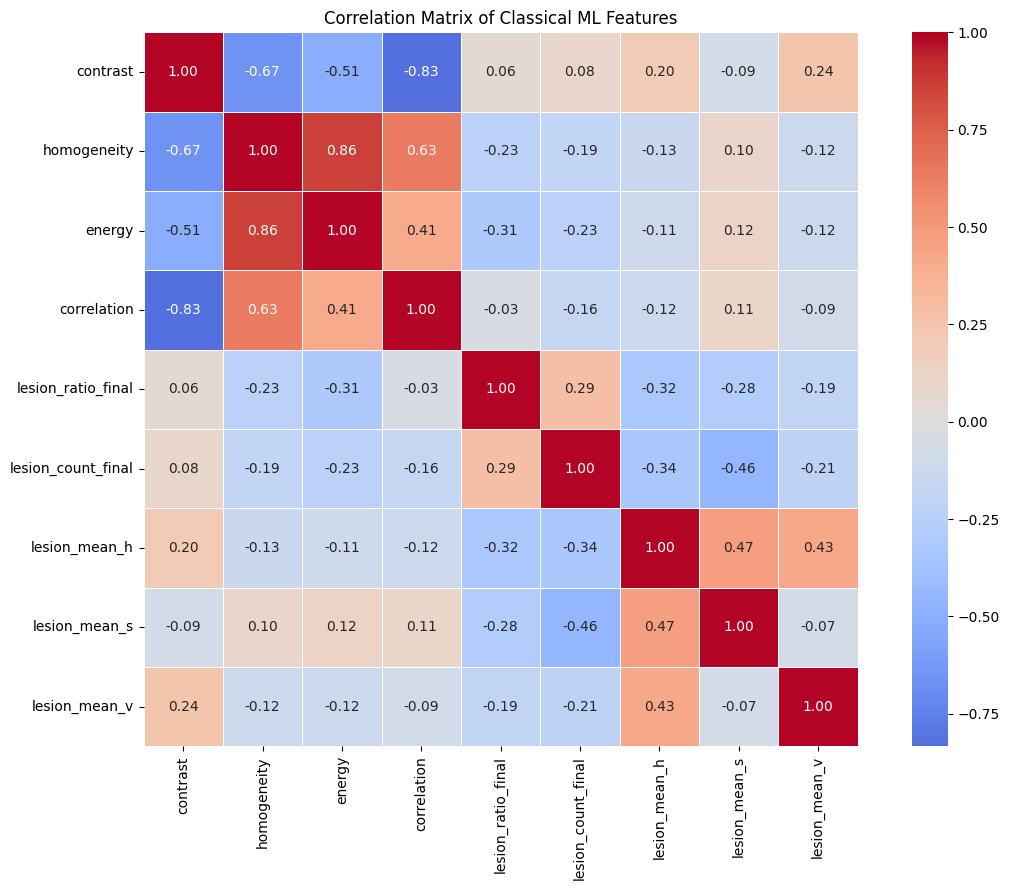

In [71]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Calculate Pearson correlation between all features
correlation_matrix = X[feature_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))

# Visualize correlations
plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix of Classical ML Features")
plt.tight_layout()
plt.show()

In [72]:
# ============================================================
# IDENTIFY HIGHLY CORRELATED FEATURE PAIRS
# ============================================================

correlation_threshold = 0.80

high_corr_pairs = []

for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):

        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= correlation_threshold:
            high_corr_pairs.append(
                (
                    feature_cols[i],
                    feature_cols[j],
                    corr_value
                )
            )

print("Highly correlated feature pairs:")

if high_corr_pairs:
    for feature_1, feature_2, corr_value in high_corr_pairs:
        print(
            f"{feature_1} <-> {feature_2}: "
            f"{corr_value:.3f}"
        )
else:
    print("No feature pairs have |correlation| >= 0.80.")

Highly correlated feature pairs:
contrast <-> correlation: -0.834
homogeneity <-> energy: 0.862


In [73]:
# ============================================================
# IQR OUTLIER ANALYSIS
# ============================================================

Q1 = X[feature_cols].quantile(0.25)
Q3 = X[feature_cols].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = (
    (X[feature_cols] < lower_bound) |
    (X[feature_cols] > upper_bound)
).sum()

outlier_percentage = (
    outlier_counts / len(X) * 100
)

outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Outlier Percentage": outlier_percentage.round(2)
})

print("IQR Outlier Summary:")
display(outlier_summary)

IQR Outlier Summary:


,Outlier Count,Outlier Percentage
contrast,497,10.37
homogeneity,0,0.00
energy,104,2.17
correlation,577,12.04
lesion_ratio_final,87,1.81
lesion_count_final,160,3.34
lesion_mean_h,2,0.04
lesion_mean_s,8,0.17
lesion_mean_v,207,4.32


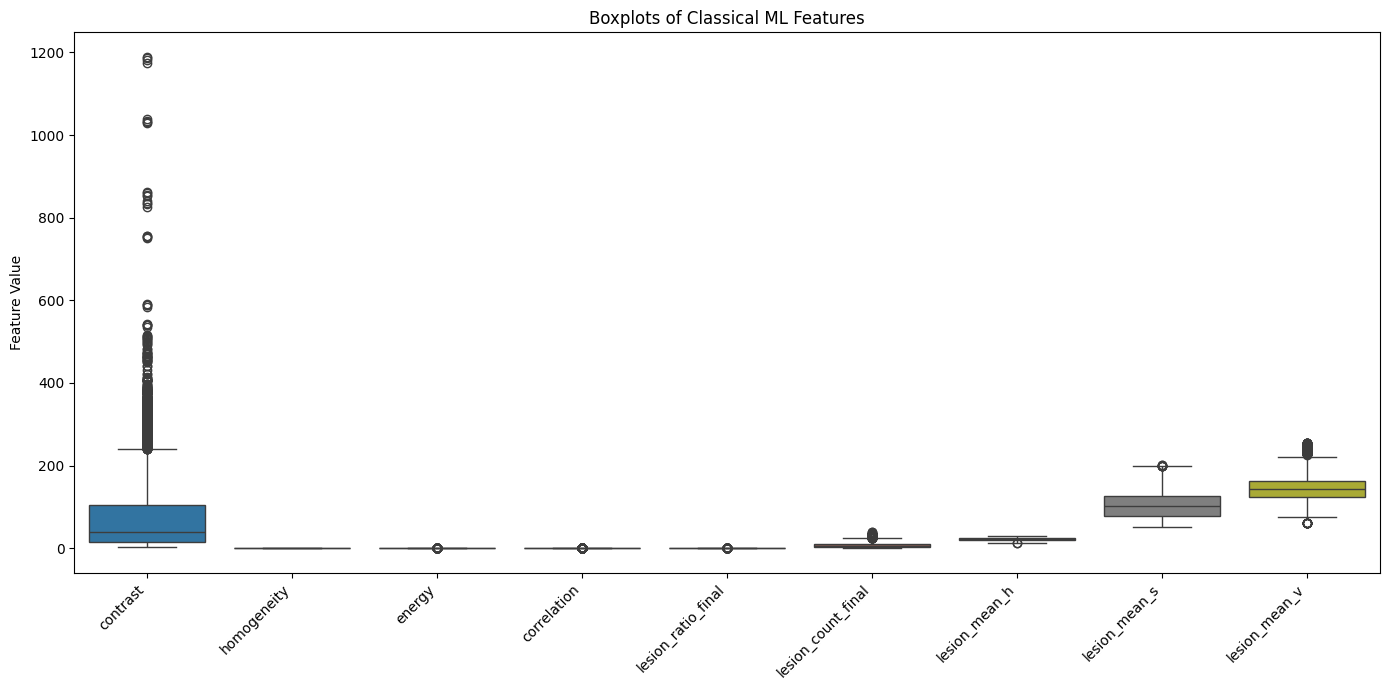

In [74]:
# ============================================================
# BOXPLOTS FOR OUTLIER VISUALIZATION
# ============================================================

plt.figure(figsize=(14, 7))

sns.boxplot(
    data=X[feature_cols]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title("Boxplots of Classical ML Features")
plt.ylabel("Feature Value")
plt.tight_layout()
plt.show()

In [75]:
print("X_train exists:", "X_train" in globals())
print("X_val exists:", "X_val" in globals())
print("X_test exists:", "X_test" in globals())

X_train exists: False
X_val exists: False
X_test exists: False


In [76]:
# ============================================================
# CLASSICAL ML - PREPARE LABELS AND STRATIFIED SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# ------------------------------------------------------------
# Step 1: Define the final 9 features
# ------------------------------------------------------------

feature_cols = [
    "contrast",
    "homogeneity",
    "energy",
    "correlation",
    "lesion_ratio_final",
    "lesion_count_final",
    "lesion_mean_h",
    "lesion_mean_s",
    "lesion_mean_v"
]

# ------------------------------------------------------------
# Step 2: Create feature matrix
# ------------------------------------------------------------

X = texture_df[feature_cols].copy()

print("Feature matrix shape:", X.shape)


# ------------------------------------------------------------
# Step 3: Create target labels
# ------------------------------------------------------------
# texture_df does not contain a "label" column.
# The labels were created from the deduplicated dataset
# using the "class_name" column.
#
# We use the existing labels list that was created during
# the final deduplicated feature-extraction pipeline.

y = pd.Series(
    labels,
    name="label"
).reset_index(drop=True)

# Make sure X and y have matching indexes
X = X.reset_index(drop=True)


# ------------------------------------------------------------
# Step 4: Verify X and y have the same number of samples
# ------------------------------------------------------------

print("Labels shape:", y.shape)

if len(X) != len(y):
    raise ValueError(
        f"Feature and label counts do not match: "
        f"X={len(X)}, y={len(y)}"
    )

print("\nX and y sizes match successfully.")


# ------------------------------------------------------------
# Step 5: Check class distribution
# ------------------------------------------------------------

print("\nOverall class distribution:")
print(y.value_counts())


# ------------------------------------------------------------
# Step 6: First stratified split
# 70% training
# 30% temporary
# ------------------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# Step 7: Split temporary data equally
# 15% validation
# 15% test
# ------------------------------------------------------------

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)


# ------------------------------------------------------------
# Step 8: Display final shapes
# ------------------------------------------------------------

print("\nFinal dataset split:")
print(
    "Training set:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation set:",
    X_val.shape,
    y_val.shape
)

print(
    "Test set:",
    X_test.shape,
    y_test.shape
)


# ------------------------------------------------------------
# Step 9: Verify class distribution in each split
# ------------------------------------------------------------

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Feature matrix shape: (4794, 9)
Labels shape: (4794,)

X and y sizes match successfully.

Overall class distribution:
label
Bacterialblight    1326
Tungro             1308
Brownspot          1200
Blast               960
Name: count, dtype: int64

Final dataset split:
Training set: (3355, 9) (3355,)
Validation set: (719, 9) (719,)
Test set: (720, 9) (720,)

Training class distribution:
label
Bacterialblight    928
Tungro             915
Brownspot          840
Blast              672
Name: count, dtype: int64

Validation class distribution:
label
Bacterialblight    199
Tungro             196
Brownspot          180
Blast              144
Name: count, dtype: int64

Test class distribution:
label
Bacterialblight    199
Tungro             197
Brownspot          180
Blast              144
Name: count, dtype: int64


In [77]:
# ============================================================
# CHECK CLASS DISTRIBUTION AFTER SPLITTING
# ============================================================

print("Training class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Training class distribution:
label
Bacterialblight    928
Tungro             915
Brownspot          840
Blast              672
Name: count, dtype: int64

Validation class distribution:
label
Bacterialblight    199
Tungro             196
Brownspot          180
Blast              144
Name: count, dtype: int64

Test class distribution:
label
Bacterialblight    199
Tungro             197
Brownspot          180
Blast              144
Name: count, dtype: int64


In [78]:
# ============================================================
# FEATURE STANDARDIZATION
# Fit scaler ONLY on training data
# ============================================================

from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (3355, 9)
Scaled validation shape: (719, 9)
Scaled test shape: (720, 9)


In [79]:
# ============================================================
# VERIFY STANDARDIZATION
# ============================================================

print("Training feature means:")
print(np.round(X_train_scaled.mean(axis=0), 4))

print("\nTraining feature standard deviations:")
print(np.round(X_train_scaled.std(axis=0), 4))

Training feature means:
[ 0. -0. -0.  0. -0.  0. -0.  0.  0.]

Training feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


# 5. Custom Convolutional Neural Network (CNN)

## Objective

The objective of this section is to develop a custom Convolutional
Neural Network (CNN) for classifying rice leaf images into four
disease classes:

1. Bacterial Blight
2. Blast
3. Brown Spot
4. Tungro

Unlike the classical machine-learning models, the CNN learns
visual features directly from the input images rather than using
the engineered nine-feature representation.

The approved project image pipeline is:

RGB conversion
→ 224 × 224 resizing
→ training-only augmentation
→ normalization to [0, 1]
→ batch size 32
→ Custom CNN
→ four-class prediction

In [80]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.1.3


In [81]:
# ============================================================
# CHECK AVAILABLE COMPUTATION DEVICE
# ============================================================

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Training will use CPU.")

GPU available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


## Reproducibility

Random seeds are fixed so that operations involving randomness are
as reproducible as possible across runs.

In [82]:
# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [83]:
# ============================================================
# PROJECT CONFIGURATION
# ============================================================

IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3

IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)

BATCH_SIZE = 32

NUM_CLASSES = 4

CLASS_NAMES = [
    "Bacterial Blight",
    "Blast",
    "Brown Spot",
    "Tungro",
]

print("Image size:", IMAGE_SIZE)
print("Channels:", CHANNELS)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)
print("Classes:", CLASS_NAMES)

Image size: (224, 224)
Channels: 3
Batch size: 32
Number of classes: 4
Classes: ['Bacterial Blight', 'Blast', 'Brown Spot', 'Tungro']


In [84]:
# ============================================================
# INSPECT CURRENT DATASET VARIABLES
# ============================================================

# Display variables that are commonly used for the cleaned
# dataset and train/validation/test splits.

candidate_variables = [
    "deduplicated_df",
    "final_ml_df",
    "image_paths",
    "labels",
    "train_df",
    "val_df",
    "test_df",
    "train_paths",
    "val_paths",
    "test_paths",
    "train_labels",
    "val_labels",
    "test_labels",
]

available_variables = {
    name: type(globals()[name]).__name__
    for name in candidate_variables
    if name in globals()
}

print("Available project variables:")
print(available_variables)

Available project variables:
{'deduplicated_df': 'DataFrame', 'final_ml_df': 'DataFrame', 'image_paths': 'list', 'labels': 'list', 'train_df': 'DataFrame', 'val_df': 'DataFrame', 'test_df': 'DataFrame', 'train_paths': 'set', 'val_paths': 'set', 'test_paths': 'set', 'val_labels': 'EagerTensor'}


In [85]:
# ============================================================
# INSPECT MASTER PIPELINE SPLIT
# ============================================================

print("TRAIN DATAFRAME")
print("Shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print(train_df.head(), "\n")

print("VALIDATION DATAFRAME")
print("Shape:", val_df.shape)
print("Columns:", val_df.columns.tolist())
print(val_df.head(), "\n")

print("TEST DATAFRAME")
print("Shape:", test_df.shape)
print("Columns:", test_df.columns.tolist())
print(test_df.head())

TRAIN DATAFRAME
Shape: (3355, 3)
Columns: ['image_path', 'class_name', 'file_hash']
                                          image_path       class_name  \
0  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
1    /content/rice_leaf_dataset/Tungro/TUNGRO5_5.jpg           Tungro   
2  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
3  /content/rice_leaf_dataset/Bacterialblight/BAC...  Bacterialblight   
4  /content/rice_leaf_dataset/Brownspot/BROWNSPOT...        Brownspot   

                                           file_hash  
0  8ebd2f18846381688862f2842b29664fa0e4e1fb60a5e7...  
1  b6c48234deefedf808ccb78bb530ae28d90eb740a3642d...  
2  e729d0c0cb8503d262518cf9975ed6bf675ffa184b95e7...  
3  e7ed207584fd800894934c4e027fa408b201369989f3ff...  
4  48d8494b94068f8abc2f6347b1fe56c6c452b18b9dd890...   

VALIDATION DATAFRAME
Shape: (719, 3)
Columns: ['image_path', 'class_name', 'file_hash']
                                          image_path clas

In [86]:
# ============================================================
# VERIFY FIXED SPLIT SIZES
# ============================================================

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Total images:", len(train_df) + len(val_df) + len(test_df))

Training images: 3355
Validation images: 719
Testing images: 720
Total images: 4794


In [87]:
# ============================================================
# VERIFY CLASS DISTRIBUTION IN EACH SPLIT
# ============================================================

print("Training class distribution:")
print(train_df["class_name"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["class_name"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["class_name"].value_counts().sort_index())

Training class distribution:
class_name
Bacterialblight    928
Blast              672
Brownspot          840
Tungro             915
Name: count, dtype: int64

Validation class distribution:
class_name
Bacterialblight    199
Blast              144
Brownspot          180
Tungro             196
Name: count, dtype: int64

Test class distribution:
class_name
Bacterialblight    199
Blast              144
Brownspot          180
Tungro             197
Name: count, dtype: int64


In [88]:
# ============================================================
# VERIFY IMAGE PATHS
# ============================================================

def check_image_paths(dataframe, split_name):
    """Check whether all image paths in a split exist."""

    missing_paths = [
        path
        for path in dataframe["image_path"]
        if not os.path.exists(path)
    ]

    print(f"{split_name}:")
    print(f"  Total paths: {len(dataframe)}")
    print(f"  Missing paths: {len(missing_paths)}")

    if missing_paths:
        print("  First missing path:")
        print(f"  {missing_paths[0]}")

    return missing_paths


train_missing = check_image_paths(train_df, "Training")
val_missing = check_image_paths(val_df, "Validation")
test_missing = check_image_paths(test_df, "Testing")

Training:
  Total paths: 3355
  Missing paths: 0
Validation:
  Total paths: 719
  Missing paths: 0
Testing:
  Total paths: 720
  Missing paths: 0


In [89]:
# ============================================================
# CLASS LABEL MAPPING
# ============================================================

CLASS_TO_INDEX = {
    "Bacterialblight": 0,
    "Blast": 1,
    "Brownspot": 2,
    "Tungro": 3,
}


def encode_labels(dataframe):
    """Convert class names into integer class labels."""

    return dataframe["class_name"].map(CLASS_TO_INDEX).to_numpy(
        dtype=np.int32
    )


train_labels = encode_labels(train_df)
val_labels = encode_labels(val_df)
test_labels = encode_labels(test_df)

print("Training labels shape:", train_labels.shape)
print("Validation labels shape:", val_labels.shape)
print("Test labels shape:", test_labels.shape)

print("\nFirst 10 training labels:")
print(train_labels[:10])

Training labels shape: (3355,)
Validation labels shape: (719,)
Test labels shape: (720,)

First 10 training labels:
[0 3 0 0 2 3 1 2 1 3]


In [90]:
# ============================================================
# CREATE TENSORFLOW DATASETS
# ============================================================

train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["image_path"].to_numpy(), train_labels)
)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_df["image_path"].to_numpy(), val_labels)
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_df["image_path"].to_numpy(), test_labels)
)

print("TensorFlow datasets created successfully.")

TensorFlow datasets created successfully.


In [91]:
# ============================================================
# IMAGE LOADING AND BASIC PREPROCESSING
# ============================================================

def load_and_preprocess_image(image_path, label):
    """
    Load an image, convert it to RGB, resize it to 224x224,
    and normalize pixel values to the range [0, 1].
    """

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False,
    )

    image = tf.image.resize(
        image,
        IMAGE_SIZE,
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [92]:
# ============================================================
# APPLY IMAGE PREPROCESSING TO THE DATASETS
# ============================================================

train_dataset = train_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE,
)

val_dataset = val_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE,
)

test_dataset = test_dataset.map(
    load_and_preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE,
)

print("Image preprocessing function applied successfully.")

Image preprocessing function applied successfully.


In [93]:
# ============================================================
# BATCHING AND PREFETCHING
# ============================================================

train_dataset = train_dataset.batch(BATCH_SIZE)
val_dataset = val_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Batching and prefetching completed.")

Batching and prefetching completed.


In [94]:
# ============================================================
# VERIFY ONE TRAINING BATCH
# ============================================================

for images, labels in train_dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image data type:", images.dtype)

    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

    print("First 10 labels:")
    print(labels[:10].numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 1.0
First 10 labels:
[0 3 0 0 2 3 1 2 1 3]


In [95]:
# ============================================================
# TRAINING-ONLY DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            mode="horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.05
        ),
        tf.keras.layers.RandomZoom(
            height_factor=0.05,
            width_factor=0.05
        ),
    ],
    name="data_augmentation",
)

print("Data augmentation layer created successfully.")

Data augmentation layer created successfully.


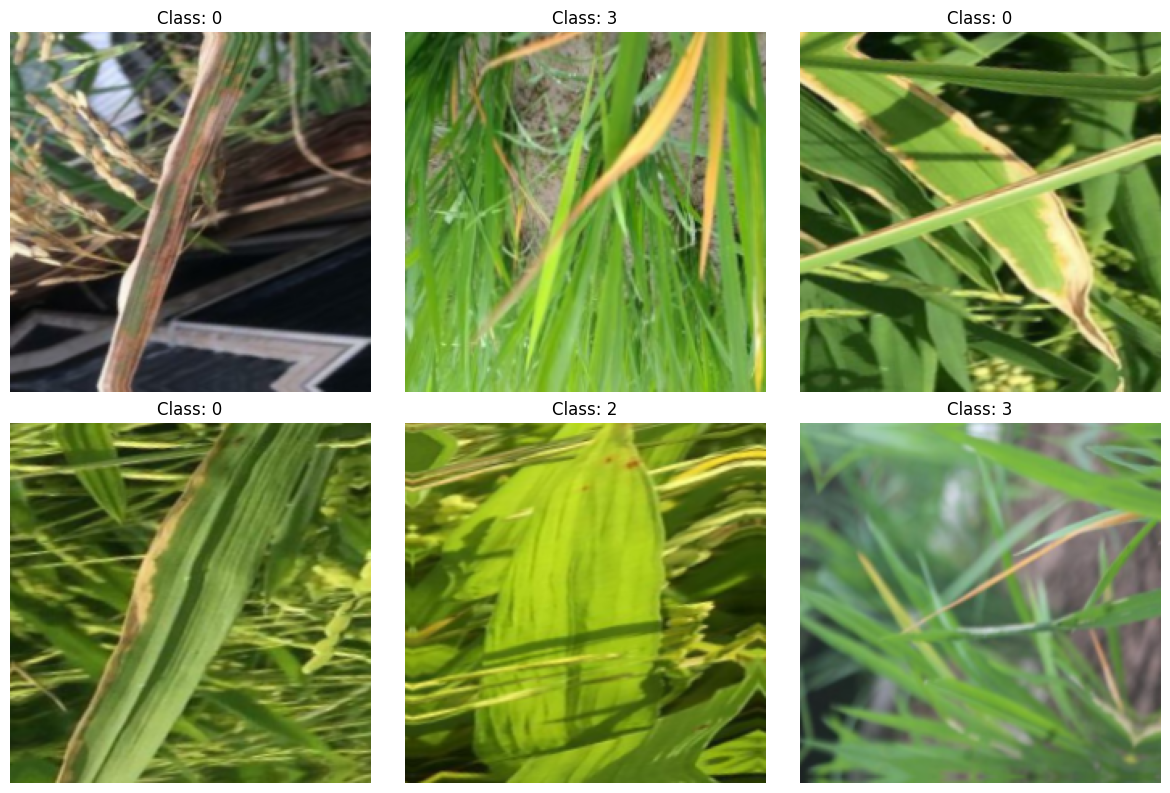

In [96]:
# ============================================================
# VISUALIZE DATA AUGMENTATION
# ============================================================

import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):
    sample_images = images[:6]
    sample_labels = labels[:6]

augmented_images = data_augmentation(
    sample_images,
    training=True,
)

plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)

    plt.imshow(augmented_images[i].numpy())
    plt.title(
        f"Class: {sample_labels[i].numpy()}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# CUSTOM CNN - REVISED BASELINE ARCHITECTURE
# ============================================================

custom_cnn = tf.keras.Sequential(
    [
        tf.keras.layers.Input(
            shape=(224, 224, 3)
        ),

        # Training-only augmentation
        data_augmentation,

        # Convolutional Block 1
        tf.keras.layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        # Convolutional Block 2
        tf.keras.layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        # Convolutional Block 3
        tf.keras.layers.Conv2D(
            filters=128,
            kernel_size=(3, 3),
            activation="relu",
            padding="same",
        ),
        tf.keras.layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        # Classification layers
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(
            128,
            activation="relu",
        ),

        tf.keras.layers.Dropout(
            0.5
        ),

        # Four disease classes
        tf.keras.layers.Dense(
            4,
            activation="softmax",
        ),
    ],
    name="custom_cnn",
)

custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,276 (430.77 KB)

 Trainable params: 110,276 (430.77 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
# ============================================================
# COMPILE CUSTOM CNN
# ============================================================

LEARNING_RATE = 0.001

custom_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

print("Custom CNN compiled successfully.")
print(f"Optimizer: Adam")
print(f"Learning rate: {LEARNING_RATE}")
print("Loss: Sparse Categorical Crossentropy")
print("Metric: Accuracy")

Custom CNN compiled successfully.
Optimizer: Adam
Learning rate: 0.001
Loss: Sparse Categorical Crossentropy
Metric: Accuracy


In [99]:
# ============================================================
# CALLBACKS
# ============================================================

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1,
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_custom_cnn.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

print("Callbacks configured successfully.")

Callbacks configured successfully.


In [100]:
# ============================================================
# BASELINE CUSTOM CNN TRAINING
# ============================================================

EPOCHS = 20

history = custom_cnn.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3390 - loss: 1.3323
Epoch 1: val_loss improved from None to 1.05054, saving model to best_custom_cnn.keras

Epoch 1: finished saving model to best_custom_cnn.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.4107 - loss: 1.2665 - val_accuracy: 0.6398 - val_loss: 1.0505 - learning_rate: 0.0010
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.5982 - loss: 1.0054
Epoch 2: val_loss improved from 1.05054 to 0.74884, saving model to best_custom_cnn.keras

Epoch 2: finished saving model to best_custom_cnn.keras
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6325 - loss: 0.9412 - val_accuracy: 0.6843 - val_loss: 0.7488 - learning_rate: 0.0010
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.7176 - loss: 0.7287
Epoch 3: val_loss improved from 0.74884 to 0.58519, saving model to best_custom_cnn.keras

Epoch 3: finished saving model to best_custom_cnn.keras
105/105 ━━━━━━━━

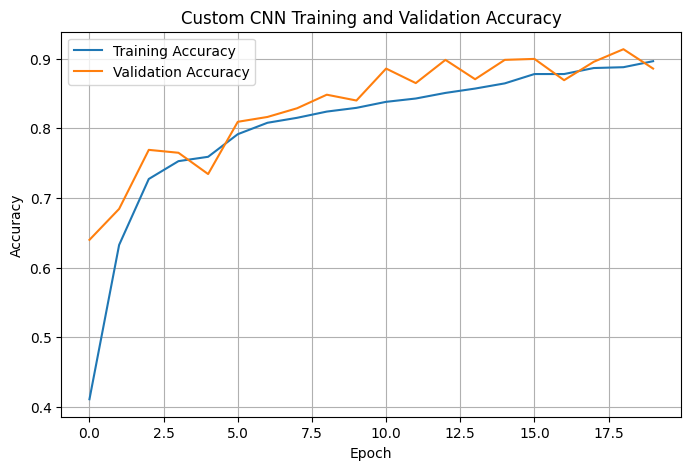

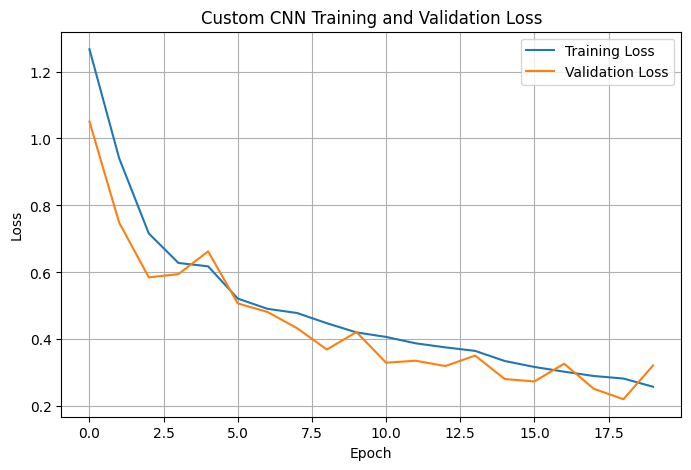

In [101]:
# ============================================================
# TRAINING AND VALIDATION CURVES
# ============================================================

import matplotlib.pyplot as plt

history_dict = history.history

# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["accuracy"],
    label="Training Accuracy",
)

plt.plot(
    history_dict["val_accuracy"],
    label="Validation Accuracy",
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    history_dict["loss"],
    label="Training Loss",
)

plt.plot(
    history_dict["val_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [102]:
# ============================================================
# BASELINE VALIDATION EVALUATION
# ============================================================

val_loss, val_accuracy = custom_cnn.evaluate(
    val_dataset,
    verbose=1,
)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9138 - loss: 0.2213
Validation Loss: 0.2213
Validation Accuracy: 0.9138


In [103]:
# ============================================================
# VALIDATION CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

y_val_true = []
y_val_pred = []

for images, labels in val_dataset:
    predictions = custom_cnn.predict(
        images,
        verbose=0,
    )

    y_val_true.extend(labels.numpy())
    y_val_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_val_true = np.array(y_val_true)
y_val_pred = np.array(y_val_pred)

print(
    classification_report(
        y_val_true,
        y_val_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
)

                  precision    recall  f1-score   support

Bacterial Blight     0.8878    0.9146    0.9010       199
           Blast     0.8769    0.7917    0.8321       144
      Brown Spot     0.9222    0.9222    0.9222       180
          Tungro     0.9559    0.9949    0.9750       196

        accuracy                         0.9138       719
       macro avg     0.9107    0.9058    0.9076       719
    weighted avg     0.9128    0.9138    0.9127       719



In [105]:
# ============================================================
# CUSTOM CNN MODEL BUILDER FOR HYPERPARAMETER TUNING
# ============================================================

def build_custom_cnn(
    learning_rate=0.0005,
    dropout_rate=0.5,
):
    """
    Build and compile the Custom CNN.

    Parameters
    ----------
    learning_rate : float
        Adam optimizer learning rate.
    dropout_rate : float
        Dropout rate before the output layer.

    Returns
    -------
    tf.keras.Model
        Compiled Custom CNN model.
    """

    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(
                shape=(224, 224, 3)
            ),

            # Training-only augmentation
            data_augmentation,

            # Convolutional Block 1
            tf.keras.layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
            ),
            tf.keras.layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # Convolutional Block 2
            tf.keras.layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
            ),
            tf.keras.layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # Convolutional Block 3
            tf.keras.layers.Conv2D(
                filters=128,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
            ),
            tf.keras.layers.MaxPooling2D(
                pool_size=(2, 2)
            ),

            # Feature aggregation
            tf.keras.layers.GlobalAveragePooling2D(),

            # Classification layer
            tf.keras.layers.Dense(
                128,
                activation="relu",
            ),

            tf.keras.layers.Dropout(
                dropout_rate
            ),

            # Four disease classes
            tf.keras.layers.Dense(
                4,
                activation="softmax",
            ),
        ],
        name="custom_cnn_tuned",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model

In [106]:
# ============================================================
# TUNING A
# ============================================================

tuning_a = build_custom_cnn(
    learning_rate=0.0005,
    dropout_rate=0.5,
)

tuning_a_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_a = tuning_a.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=tuning_a_callbacks,
    verbose=1,
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - accuracy: 0.3973 - loss: 1.2806 - val_accuracy: 0.5424 - val_loss: 1.1211 - learning_rate: 5.0000e-04
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.5881 - loss: 1.0337 - val_accuracy: 0.6384 - val_loss: 0.8982 - learning_rate: 5.0000e-04
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.6712 - loss: 0.8758 - val_accuracy: 0.6690 - val_loss: 0.7586 - learning_rate: 5.0000e-04
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.7154 - loss: 0.7362 - val_accuracy: 0.6968 - val_loss: 0.6645 - learning_rate: 5.0000e-04
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.7425 - loss: 0.6498 - val_accuracy: 0.7622 - val_loss: 0.5703 - learning_rate: 5.0000e-04
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step - accuracy: 0.7499 - loss: 0.6168 - val_accuracy: 0.7789 - val_loss: 0.5166 - learning_rate: 5.0000e-04
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step 

In [107]:
# ============================================================
# TUNING B
# ============================================================

tuning_b = build_custom_cnn(
    learning_rate=0.0005,
    dropout_rate=0.3,
)

tuning_b_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1,
    ),
]

history_b = tuning_b.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    callbacks=tuning_b_callbacks,
    verbose=1,
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.3928 - loss: 1.2941 - val_accuracy: 0.5688 - val_loss: 1.1217 - learning_rate: 5.0000e-04
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 11s 71ms/step - accuracy: 0.6006 - loss: 0.9979 - val_accuracy: 0.6537 - val_loss: 0.8561 - learning_rate: 5.0000e-04
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.6939 - loss: 0.8142 - val_accuracy: 0.7218 - val_loss: 0.7093 - learning_rate: 5.0000e-04
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - accuracy: 0.7317 - loss: 0.6988 - val_accuracy: 0.7385 - val_loss: 0.6288 - learning_rate: 5.0000e-04
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.7386 - loss: 0.6353 - val_accuracy: 0.7677 - val_loss: 0.5448 - learning_rate: 5.0000e-04
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.7702 - loss: 0.5761 - val_accuracy: 0.7288 - val_loss: 0.5653 - learning_rate: 5.0000e-04
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - ac

In [108]:
# ============================================================
# VALIDATION ACCURACY COMPARISON
# ============================================================

baseline_val_accuracy = 0.9138
baseline_weighted_f1 = 0.9127

tuning_a_val_loss, tuning_a_val_accuracy = tuning_a.evaluate(
    val_dataset,
    verbose=0,
)

tuning_b_val_loss, tuning_b_val_accuracy = tuning_b.evaluate(
    val_dataset,
    verbose=0,
)

print("CUSTOM CNN HYPERPARAMETER COMPARISON")
print("-" * 60)

print(
    f"Baseline  | LR=0.001  | Dropout=0.5 | "
    f"Val Accuracy={baseline_val_accuracy:.4f} | "
    f"Weighted F1={baseline_weighted_f1:.4f}"
)

print(
    f"Tuning A  | LR=0.0005 | Dropout=0.5 | "
    f"Val Accuracy={tuning_a_val_accuracy:.4f}"
)

print(
    f"Tuning B  | LR=0.0005 | Dropout=0.3 | "
    f"Val Accuracy={tuning_b_val_accuracy:.4f}"
)

CUSTOM CNN HYPERPARAMETER COMPARISON
------------------------------------------------------------
Baseline  | LR=0.001  | Dropout=0.5 | Val Accuracy=0.9138 | Weighted F1=0.9127
Tuning A  | LR=0.0005 | Dropout=0.5 | Val Accuracy=0.8707
Tuning B  | LR=0.0005 | Dropout=0.3 | Val Accuracy=0.8651


In [109]:
# ============================================================
# FINAL CUSTOM CNN TEST EVALUATION
# ============================================================

test_loss, test_accuracy = custom_cnn.evaluate(
    test_dataset,
    verbose=1,
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.9097 - loss: 0.2386
Test Loss: 0.2386
Test Accuracy: 0.9097


In [110]:
# ============================================================
# FINAL TEST CLASSIFICATION REPORT
# AND CONFUSION MATRIX
# ============================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

y_test_true = []
y_test_pred = []

for images, labels in test_dataset:
    predictions = custom_cnn.predict(
        images,
        verbose=0,
    )

    y_test_true.extend(labels.numpy())
    y_test_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)

print("CUSTOM CNN - FINAL TEST CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test_true,
        y_test_pred,
        target_names=CLASS_NAMES,
        digits=4,
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
)

print("\nConfusion Matrix:")
print(cm)

CUSTOM CNN - FINAL TEST CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Bacterial Blight     0.8689    0.8995    0.8840       199
           Blast     0.9070    0.8125    0.8571       144
      Brown Spot     0.9153    0.9000    0.9076       180
          Tungro     0.9471    1.0000    0.9728       197

        accuracy                         0.9097       720
       macro avg     0.9096    0.9030    0.9054       720
    weighted avg     0.9095    0.9097    0.9088       720


Confusion Matrix:
[[179   4   9   7]
 [ 19 117   6   2]
 [  8   8 162   2]
 [  0   0   0 197]]


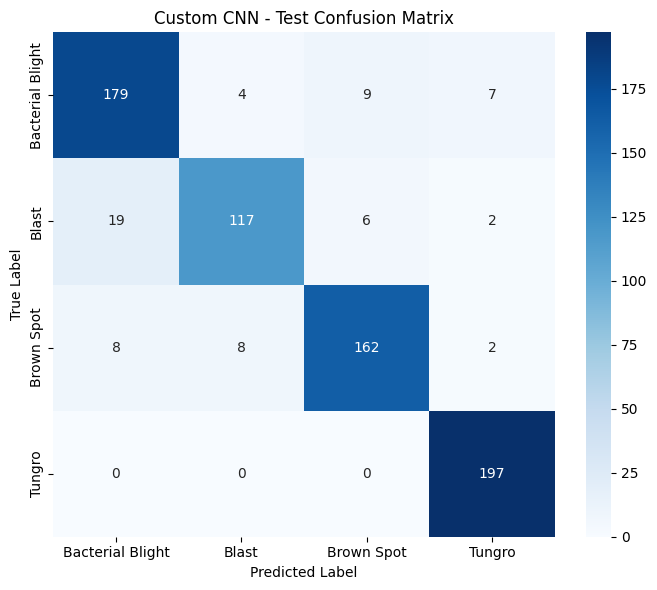

In [111]:
# ============================================================
# FINAL TEST CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Custom CNN - Test Confusion Matrix")

plt.tight_layout()
plt.show()

In [112]:
# ============================================================
# SAVE FINAL CUSTOM CNN
# ============================================================

FINAL_MODEL_PATH = "Custom_CNN_Final.keras"

custom_cnn.save(FINAL_MODEL_PATH)

print(f"Final Custom CNN saved to: {FINAL_MODEL_PATH}")

Final Custom CNN saved to: Custom_CNN_Final.keras


In [113]:
# ============================================================
# FINAL CUSTOM CNN SANITY CHECK
# ============================================================

print("FINAL CUSTOM CNN SANITY CHECK")
print("=" * 50)

print(f"Test samples evaluated: {len(y_test_true)}")
print(f"Correct predictions: {np.sum(y_test_true == y_test_pred)}")
print(f"Incorrect predictions: {np.sum(y_test_true != y_test_pred)}")
print(f"Test accuracy: {test_accuracy:.4f}")

print("\nConfusion matrix total:")
print(cm.sum())

print("\nExpected test samples: 720")
print(f"Actual confusion matrix samples: {cm.sum()}")

FINAL CUSTOM CNN SANITY CHECK
Test samples evaluated: 720
Correct predictions: 655
Incorrect predictions: 65
Test accuracy: 0.9097

Confusion matrix total:
720

Expected test samples: 720
Actual confusion matrix samples: 720
